In [1]:
import cv2
import numpy as np
import pandas as pd
import os
import sys
import math
from matplotlib import pyplot as plt
from IPython.display import display, clear_output
from skimage import data


# Agregar la ruta al folder src/
sys.path.append(os.path.abspath('../src'))
from matching import *
from utils import *

In [2]:
# Directorios de salida
BASE_DIR = 'C:/Users/deivi/OneDrive/Escritorio/U/ComputerVision/Trabajo2/'#Modificar
SYNTHETIC_DATA_DIR = os.path.join(BASE_DIR, 'data/synthetic/')
FIGURES_DIR = os.path.join(BASE_DIR, 'data/figures/')
ORIGINAL_DIR = os.path.join(BASE_DIR, 'data/original/')

In [3]:
# Asumo que las imágenes A, B y C son las tres vistas del comedor.
IMG_A_PATH = 'IMG01.jpg'  
IMG_B_PATH = 'IMG02.jpg'
IMG_C_PATH = 'IMG03.jpg'

Imágenes reales cargadas exitosamente. Dimensiones (A): (633, 475)


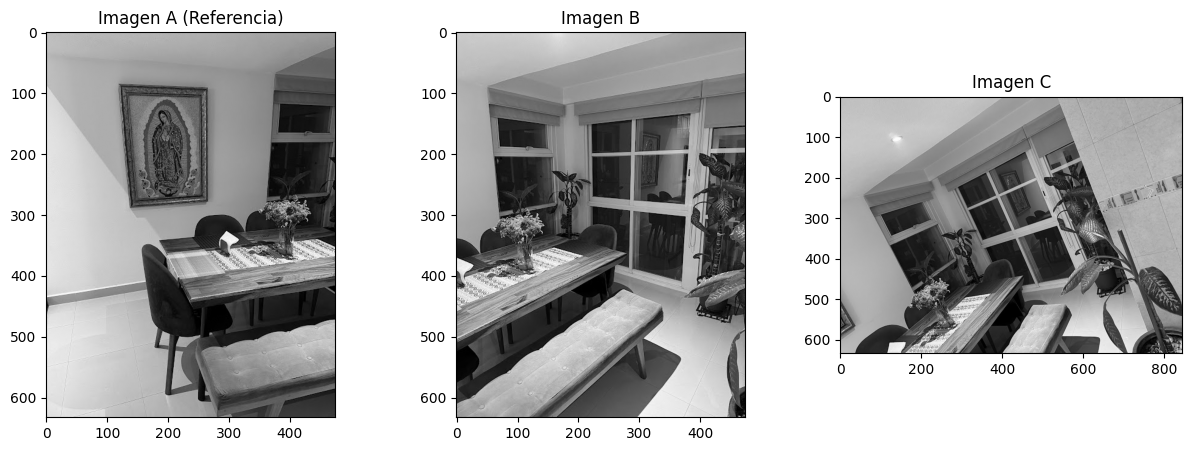

In [4]:
try:
    # Cargar imágenes en color para visualización, pero usar gris para detección
    img_A_color = cv2.imread(os.path.join(ORIGINAL_DIR,IMG_A_PATH))
    img_B_color = cv2.imread(os.path.join(ORIGINAL_DIR,IMG_B_PATH))
    img_C_color = cv2.imread(os.path.join(ORIGINAL_DIR,IMG_C_PATH))

    if img_A_color is None or img_B_color is None or img_C_color is None:
        raise FileNotFoundError("Una o más imágenes reales no se encontraron. Revisa los nombres y rutas.")

    # Convertir a escala de grises para el procesamiento (es más eficiente)
    img_A = cv2.cvtColor(img_A_color, cv2.COLOR_BGR2GRAY)
    img_B = cv2.cvtColor(img_B_color, cv2.COLOR_BGR2GRAY)
    img_C = cv2.cvtColor(img_C_color, cv2.COLOR_BGR2GRAY)

    print("Imágenes reales cargadas exitosamente. Dimensiones (A):", img_A.shape)

except FileNotFoundError as e:
    print(f"ERROR: {e}")
    # Detener si no se encuentran las imágenes reales
    raise

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(img_A, cmap='gray'); plt.title('Imagen A (Referencia)')
plt.subplot(1, 3, 2); plt.imshow(img_B, cmap='gray'); plt.title('Imagen B')
plt.subplot(1, 3, 3); plt.imshow(img_C, cmap='gray'); plt.title('Imagen C')
plt.show() # 

# Inicializar un diccionario para almacenar las Homografías
H_storage = {}

In [5]:
DETECTOR_REAL = "SIFT"  # El mejor detector encontrado en la Parte 1
RANSAC_OPTIMO = 5.0     # El umbral RANSAC que dio el mejor balance (ej. 5.0)
RATIO_UMBRAL = 0.75     # Umbral de Lowe

print(f"--- Registro A <-> B (Detector: {DETECTOR_REAL}) ---")

--- Registro A <-> B (Detector: SIFT) ---


In [6]:
# Imagen A (img_A) es la Base, Imagen B (img_B) es la Deformada.
# Detección
kp_A, des_A = detectar_y_describir(img_A, DETECTOR_REAL)
kp_B, des_B = detectar_y_describir(img_B, DETECTOR_REAL)

# Matching
matches_AB = emparejar_y_filtrar(des_B, des_A, DETECTOR_REAL, ratio_umbral=RATIO_UMBRAL)
# NOTA: La dirección es Des_B (query) -> Des_A (train) porque queremos H_AB
# que mapee puntos de B a A.

print(f"Keypoints A/B: {len(kp_A)} / {len(kp_B)}. Matches iniciales: {len(matches_AB)}")

Keypoints A/B: 673 / 781. Matches iniciales: 131


In [7]:
# H_AB mapea: Puntos de B (src) -> Puntos de A (dst)
pts_B = np.float32([kp_B[m.queryIdx].pt for m in matches_AB]).reshape(-1, 1, 2)
pts_A = np.float32([kp_A[m.trainIdx].pt for m in matches_AB]).reshape(-1, 1, 2)

H_AB, inliers_AB = cv2.findHomography(pts_B, pts_A, cv2.RANSAC, RANSAC_OPTIMO)
# La matriz H_AB está normalizada dentro de findHomography, pero la normalizamos 
# para guardarla en el diccionario.
H_AB = normalizar_homografia(H_AB)

if H_AB is None:
    print("¡ERROR! No se pudo estimar H_AB. Pocos inliers.")
    raise ValueError("Fallo en la estimación de H_AB.")

inliers_AB = inliers_AB.ravel().astype(bool)
corrected_matches_AB = [m for m, inl in zip(matches_AB, inliers_AB) if inl]

H_storage['H_AB'] = H_AB

print(f"H_AB estimada con {np.sum(inliers_AB)} inliers (RANSAC {RANSAC_OPTIMO}).")

H_AB estimada con 115 inliers (RANSAC 5.0).


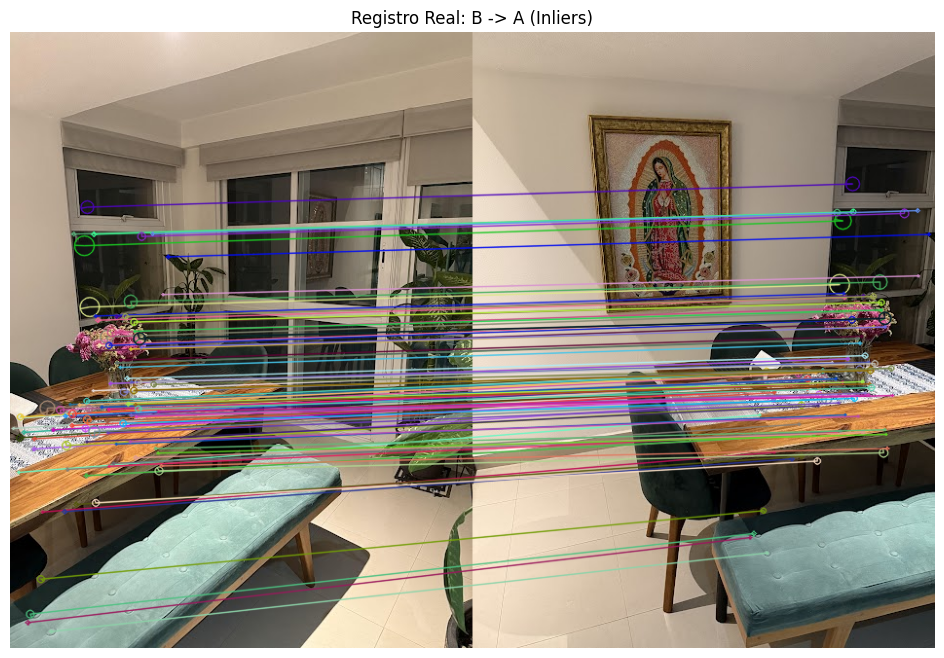

Figura guardada en: C:/Users/deivi/OneDrive/Escritorio/U/ComputerVision/Trabajo2/data/figures/registro_AB_inliers.png


In [8]:
# Visualizar los inliers de la Homografía H_AB
draw_matches_and_save(
    img_B_color, kp_B, img_A_color, kp_A, 
    corrected_matches_AB[:100], 
    'Registro Real: B -> A (Inliers)',
    FIGURES_DIR,
    'registro_AB_inliers.png'
)

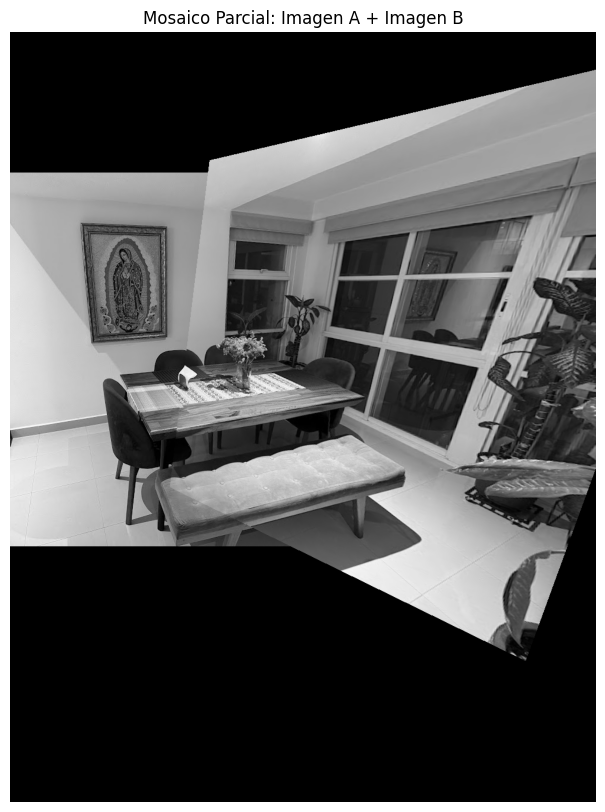

In [9]:
# Prueba de Unificación (A + B)
mosaico_AB = unificar_dos_imagenes(img_A_color, img_B_color, H_AB)

plt.figure(figsize=(10, 10))
plt.imshow(mosaico_AB, cmap='gray')
plt.title('Mosaico Parcial: Imagen A + Imagen B')
plt.axis('off')
plt.show()

In [10]:
# Preparación de la Base (Mosaico A+B)
# Asumo que mosaico_AB es la imagen en color (BGR) devuelta por unificar_dos_imagenes
mosaico_AB_color = mosaico_AB
mosaico_AB_gray = cv2.cvtColor(mosaico_AB_color, cv2.COLOR_BGR2GRAY)

print("--- Registro C <-> (A+B) ---")

--- Registro C <-> (A+B) ---


In [11]:
# Detección y Matching (C al Mosaico A+B)
# Imagen C (img_C) es la Deformada, Mosaico A+B (mosaico_AB) es la Base.

# Detección
kp_AB, des_AB = detectar_y_describir(mosaico_AB_gray, DETECTOR_REAL)
kp_C, des_C = detectar_y_describir(img_C, DETECTOR_REAL) # img_C es gris de Celda 12

# Matching (Des_C (query) -> Des_AB (train))
matches_C_AB = emparejar_y_filtrar(des_C, des_AB, DETECTOR_REAL, ratio_umbral=RATIO_UMBRAL)

print(f"Keypoints (A+B)/C: {len(kp_AB)} / {len(kp_C)}. Matches iniciales: {len(matches_C_AB)}")

Keypoints (A+B)/C: 2276 / 1455. Matches iniciales: 200


In [12]:
# Estimación de Homografía H_C_AB

# H_C_AB mapea: Puntos de C (src) -> Puntos de A+B (dst)
pts_C = np.float32([kp_C[m.queryIdx].pt for m in matches_C_AB]).reshape(-1, 1, 2)
pts_AB = np.float32([kp_AB[m.trainIdx].pt for m in matches_C_AB]).reshape(-1, 1, 2)

H_C_AB, inliers_C_AB = cv2.findHomography(pts_C, pts_AB, cv2.RANSAC, RANSAC_OPTIMO)
H_C_AB = normalizar_homografia(H_C_AB)

if H_C_AB is None:
    print("¡ERROR! No se pudo estimar H_C_AB. Pocos inliers.")
    raise ValueError("Fallo en la estimación de H_C_AB.")

H_storage['H_C_AB'] = H_C_AB
print(f"H_C_AB estimada con {np.sum(inliers_C_AB.ravel())} inliers.")

H_C_AB estimada con 121 inliers.


In [13]:
# 4. Unificación Final (A+B) + C

# Ahora usamos la función unificar_dos_imagenes:
# img_base_color = mosaico_AB_color
# img_to_warp_color = img_C_color
# H = H_C_AB

mosaico_final = unificar_dos_imagenes(
    mosaico_AB_color,      # Base: El mosaico que ya tiene A+B
    img_C_color,           # Imagen a deformar: Imagen C
    H_C_AB                 # Homografía que mapea C -> (A+B)
)


!!! DIAGNÓSTICO: Mismatch Dimensional entre ROI ((1027, 992)) e img_base ((1304, 992)) !!!
Este mismatch es la causa del IndexError. Ajuste los límites de la ROI para que coincidan.


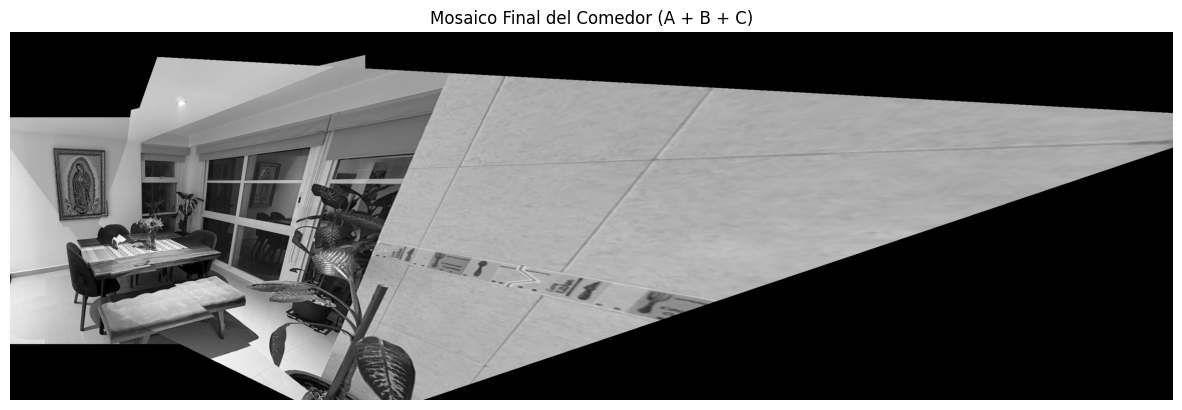

In [14]:
# 5. Visualización del Mosaico Final
plt.figure(figsize=(15, 10))
# OpenCV carga en BGR, Matplotlib requiere RGB
mosaico_final_rgb = cv2.cvtColor(mosaico_final, cv2.COLOR_BGR2RGB) 
plt.imshow(mosaico_final_rgb)
plt.title('Mosaico Final del Comedor (A + B + C)')
plt.axis('off')
plt.show()